## **Importing Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)

## **Loading Dataset**

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
df = df.drop("Student_ID", axis=1)

In [4]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## **Data Preprocessing**

In [5]:
numeric_cols = df.select_dtypes(exclude="object").columns.tolist()
catagorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols, catagorical_cols

(['Pre_Semester_GPA',
  'Weekly_GenAI_Hours',
  'Tool_Diversity',
  'Paid_Subscription',
  'Traditional_Study_Hours',
  'Perceived_AI_Dependency',
  'Anxiety_Level_During_Exams',
  'Post_Semester_GPA',
  'Skill_Retention_Score'],
 ['Major_Category',
  'Year_of_Study',
  'Primary_Use_Case',
  'Prompt_Engineering_Skill',
  'Institutional_Policy',
  'Burnout_Risk_Level'])

### *1. Outlier Handling*

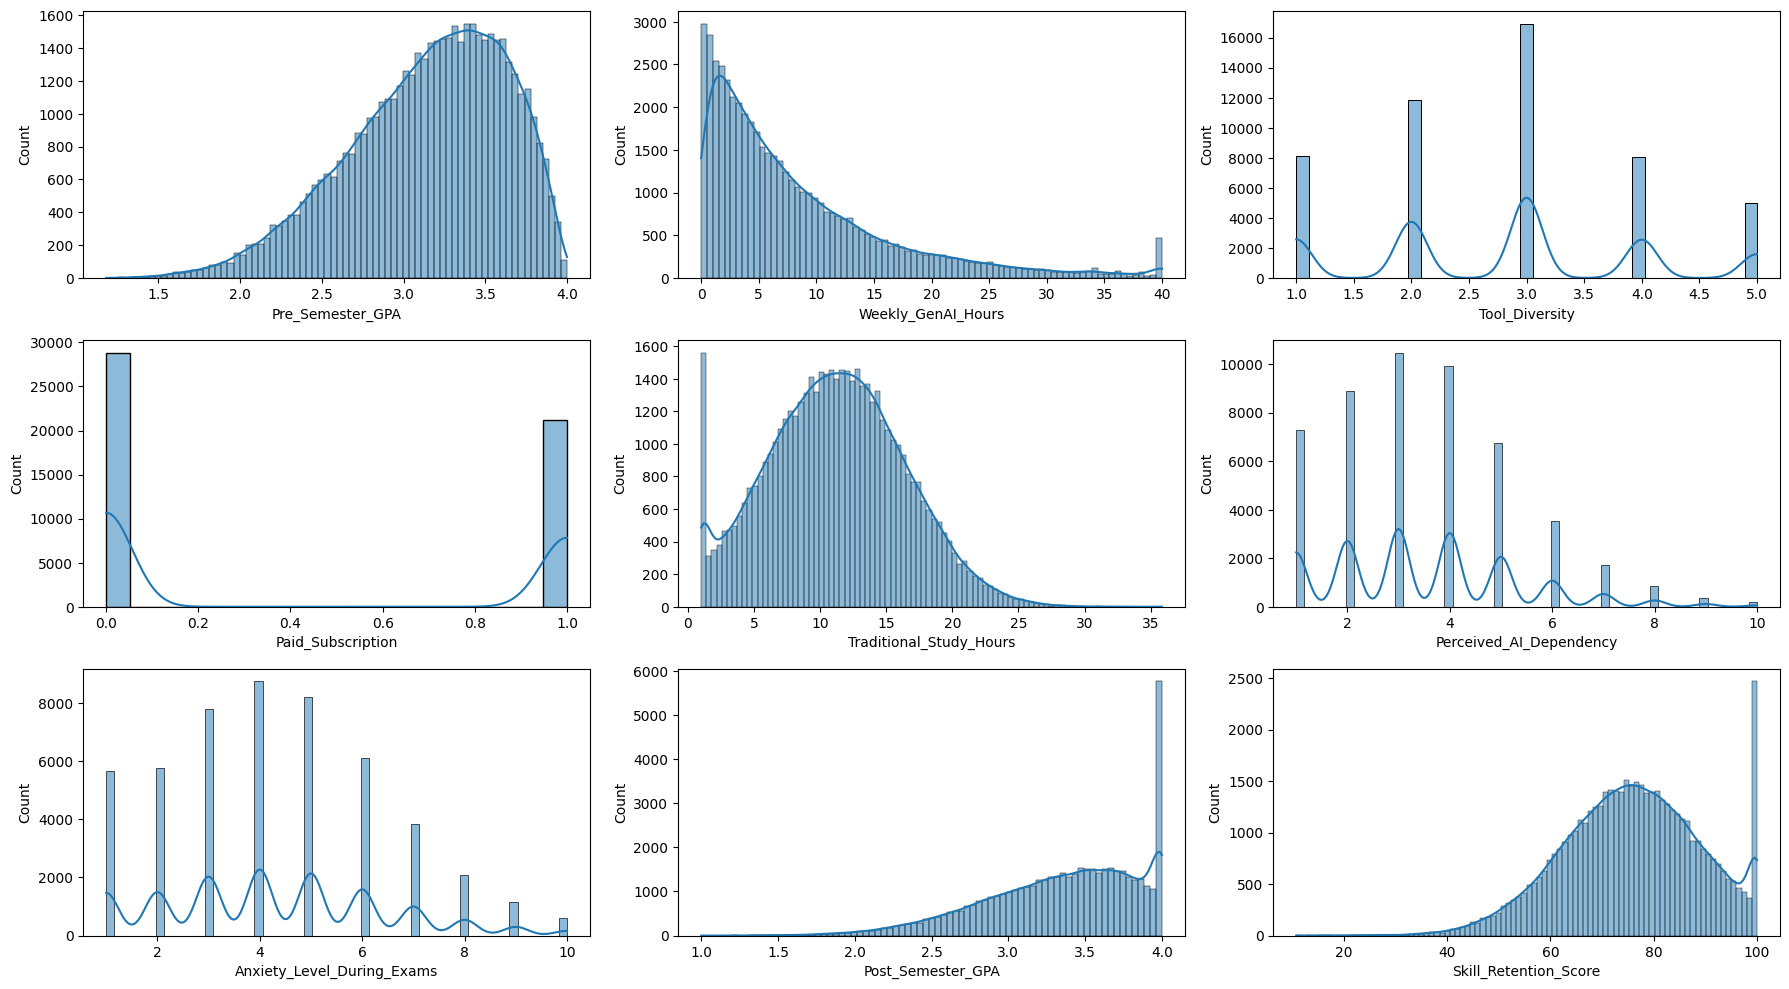

In [6]:
plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    plt.subplot(3, 3, (i+1))
    sns.histplot(data=df, x=numeric_cols[i], kde=True)
plt.tight_layout()

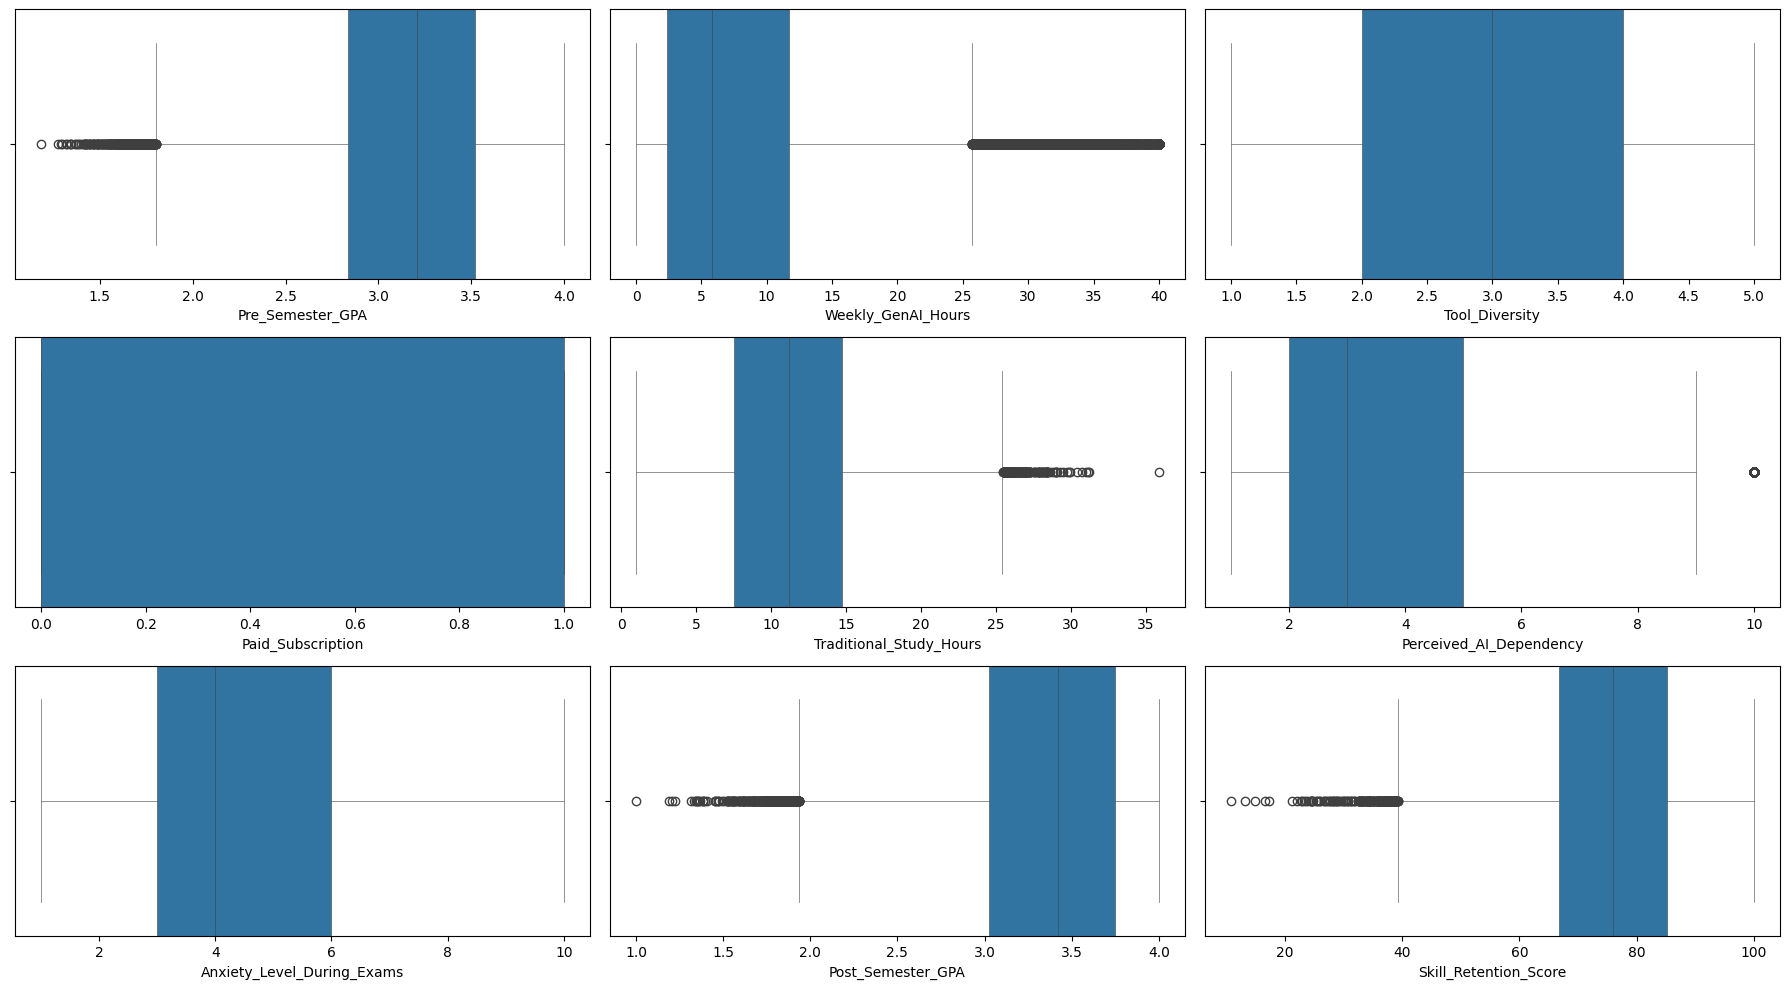

In [7]:
plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    plt.subplot(3, 3, (i+1))
    sns.boxplot(data=df, x=numeric_cols[i], linewidth=0.4, width=1.5)
plt.tight_layout()

In [8]:
def z_score(df: pd.DataFrame, cols: list, threshold: float = 3.0) -> pd.DataFrame:
    scores = (df[cols] - df[cols].mean()) / df[cols].std()
    return df[(scores.abs() <= threshold).all(axis=1)]

In [9]:
df = z_score(df, numeric_cols, 2.5)

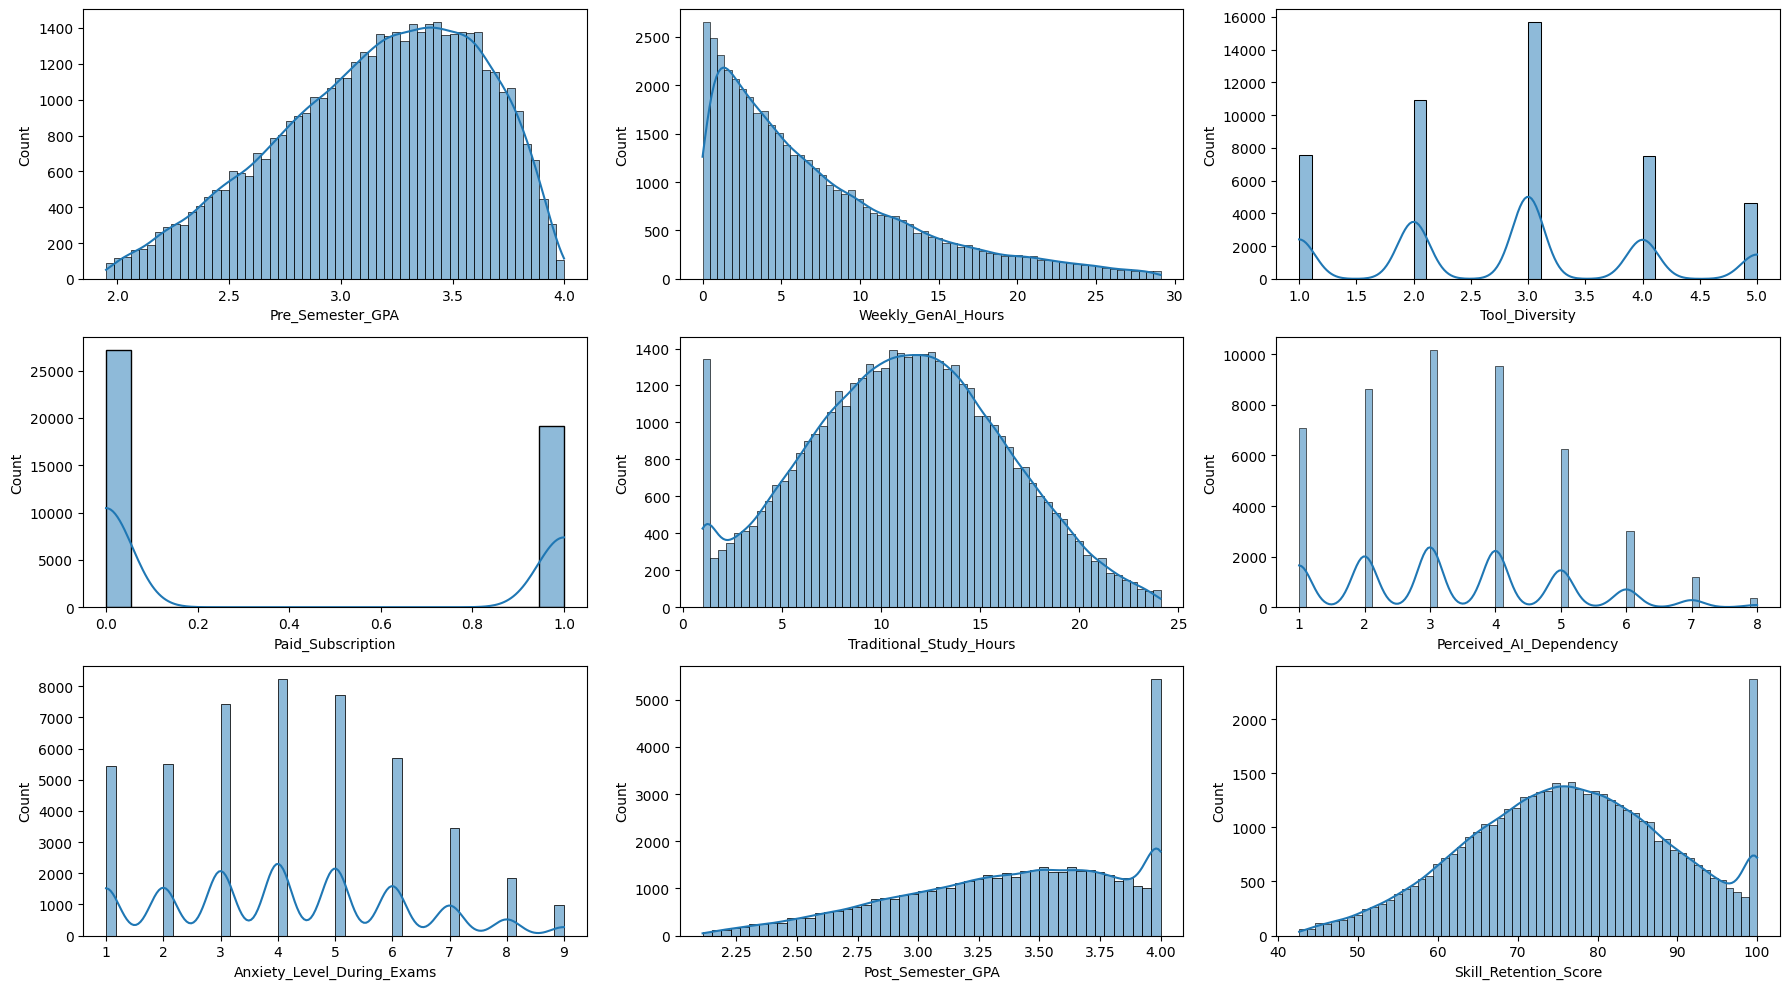

In [10]:
plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    plt.subplot(3, 3, (i+1))
    sns.histplot(data=df, x=numeric_cols[i], kde=True)
plt.tight_layout()

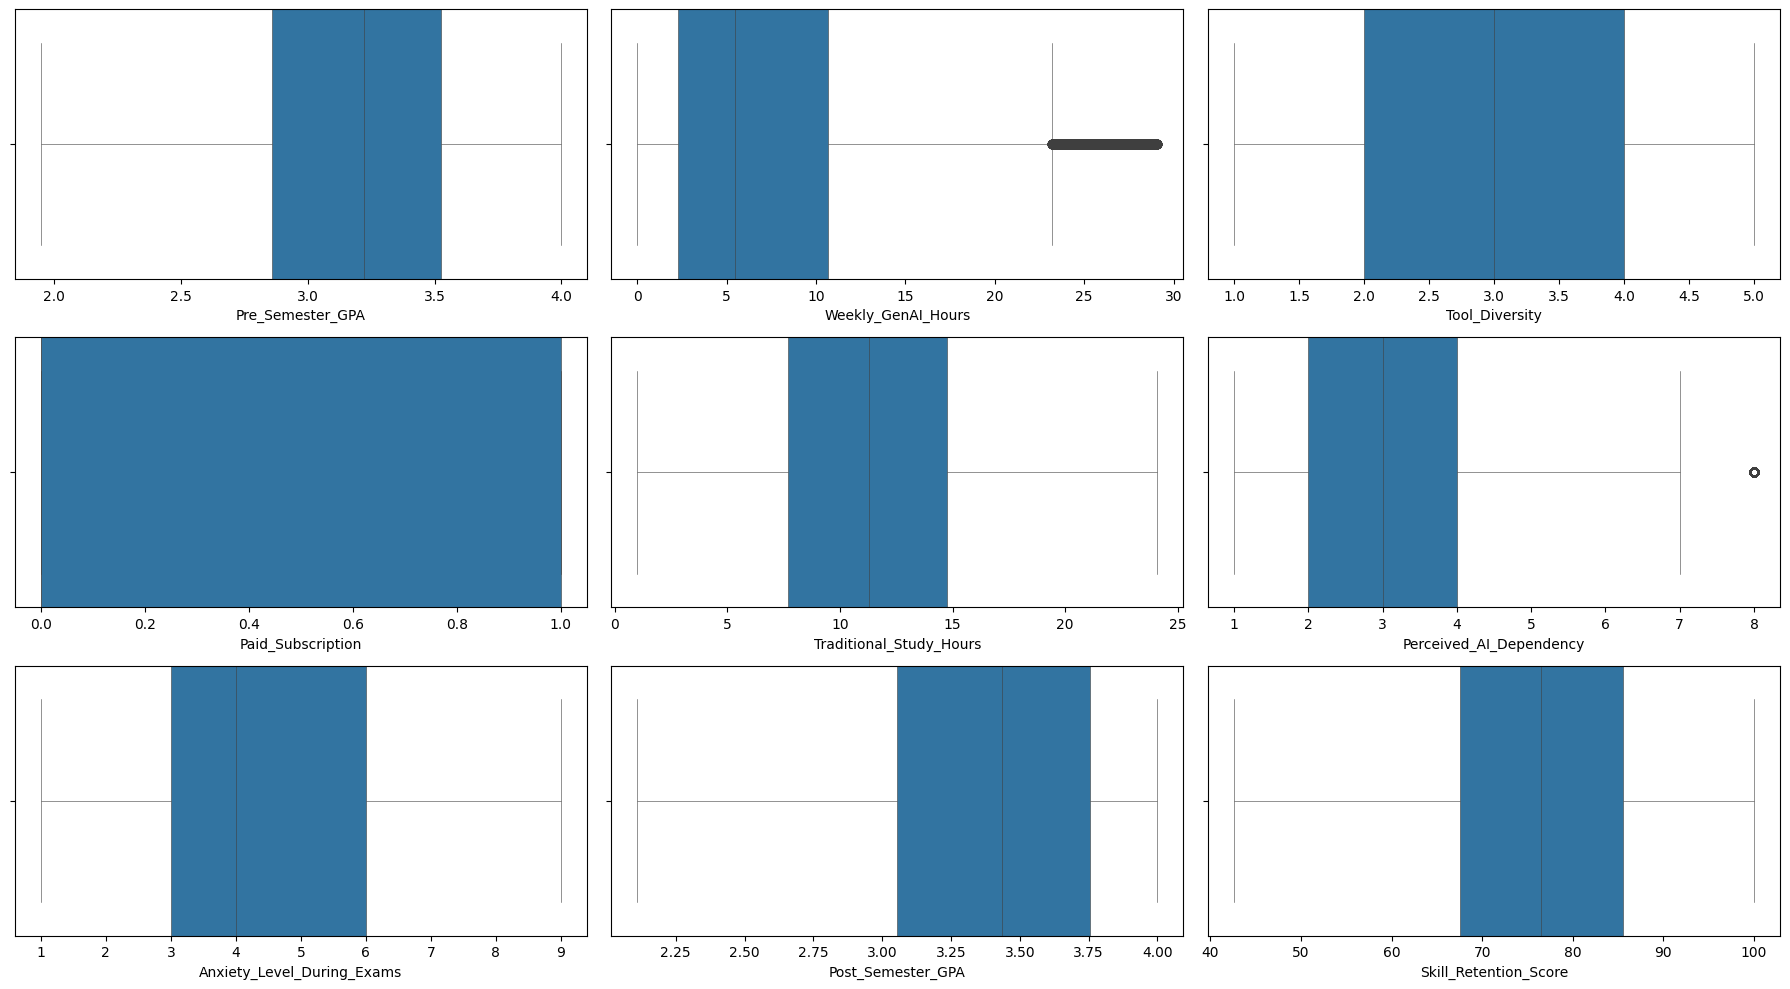

In [11]:
plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    plt.subplot(3, 3, (i+1))
    sns.boxplot(data=df, x=numeric_cols[i], linewidth=0.4, width=1.5)
plt.tight_layout()

### *2. Encoding Features*

In [12]:
df[catagorical_cols].head()

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
0,Humanities,Senior,Copywriting/Drafting,Beginner,Allowed_With_Citation,High
1,Medical,Junior,Ideation,Advanced,Allowed_With_Citation,Low
2,Business,Freshman,Summarizing_Reading,Beginner,Strict_Ban,Medium
3,Business,Senior,Copywriting/Drafting,Intermediate,Allowed_With_Citation,Medium
4,STEM,Sophomore,Debugging/Troubleshooting,Advanced,Allowed_With_Citation,Medium


In [13]:
for i in catagorical_cols:
    print(i)
    print(df[i].nunique())
    print(df[i].unique())
    print("\n")

Major_Category
5
['Humanities' 'Medical' 'Business' 'STEM' 'Arts']


Year_of_Study
5
['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']


Primary_Use_Case
5
['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']


Prompt_Engineering_Skill
3
['Beginner' 'Advanced' 'Intermediate']


Institutional_Policy
3
['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']


Burnout_Risk_Level
3
['High' 'Low' 'Medium']




In [14]:
df = pd.get_dummies(data=df, columns=catagorical_cols, dtype=float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46272 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Pre_Semester_GPA                            46272 non-null  float64
 1   Weekly_GenAI_Hours                          46272 non-null  float64
 2   Tool_Diversity                              46272 non-null  int64  
 3   Paid_Subscription                           46272 non-null  bool   
 4   Traditional_Study_Hours                     46272 non-null  float64
 5   Perceived_AI_Dependency                     46272 non-null  int64  
 6   Anxiety_Level_During_Exams                  46272 non-null  int64  
 7   Post_Semester_GPA                           46272 non-null  float64
 8   Skill_Retention_Score                       46272 non-null  float64
 9   Major_Category_Arts                         46272 non-null  float64
 10  Major_Category_

In [15]:
df.isna().sum()

Pre_Semester_GPA                              0
Weekly_GenAI_Hours                            0
Tool_Diversity                                0
Paid_Subscription                             0
Traditional_Study_Hours                       0
Perceived_AI_Dependency                       0
Anxiety_Level_During_Exams                    0
Post_Semester_GPA                             0
Skill_Retention_Score                         0
Major_Category_Arts                           0
Major_Category_Business                       0
Major_Category_Humanities                     0
Major_Category_Medical                        0
Major_Category_STEM                           0
Year_of_Study_Freshman                        0
Year_of_Study_Graduate                        0
Year_of_Study_Junior                          0
Year_of_Study_Senior                          0
Year_of_Study_Sophomore                       0
Primary_Use_Case_Copywriting/Drafting         0
Primary_Use_Case_Debugging/Troubleshooti

In [16]:
df.to_csv("preprocessed_data.csv")